In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler  # ¡IMPORTANTE! Esta línea faltaba
import warnings
warnings.filterwarnings('ignore')

In [55]:
X_train = pd.read_csv('../Datos/preparados/TrainX.csv')
y_train = pd.read_csv('../Datos/preparados/TrainY.csv')
X_val = pd.read_csv('../Datos/preparados/ValidationX.csv') 
y_val = pd.read_csv('../Datos/preparados/ValidationY.csv')
X_test = pd.read_csv('../Datos/preparados/TestX.csv')
y_test = pd.read_csv('../Datos/preparados/TestY.csv')

In [56]:
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"   X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"   Nombre: {y_train.columns[0]}")
print(f"   Rango: {y_train.iloc[:, 0].min():.2f} a {y_train.iloc[:, 0].max():.2f}")

   X_train: (461100, 2), y_train: (461100, 1)
   X_val: (115276, 2), y_val: (115276, 1)
   X_test: (144095, 2), y_test: (144095, 1)
   Nombre: ROI
   Rango: -0.99 a 498.92


In [59]:
class SVDRegression:
    def __init__(self, n_components=None, algorithm='randomized', random_state=42, scale_y=True):
        self.n_components = n_components
        self.algorithm = algorithm
        self.random_state = random_state
        self.svd = None
        self.regressor = None
        self.scaler = StandardScaler()
        self.y_scaler = StandardScaler() if scale_y else None
        self.actual_components = None
        self.scale_y = scale_y

    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        y_scaled = self.y_scaler.fit_transform(y)[:, 0] if self.scale_y else y.values.ravel()

        n_samples, n_features = X_scaled.shape
        max_possible = min(n_samples, n_features)

        if self.n_components is None or self.n_components > max_possible:
            self.actual_components = max_possible
        else:
            self.actual_components = self.n_components

        print(f"Usando {self.actual_components} componentes de {max_possible} posibles")

        self.svd = TruncatedSVD(
            n_components=self.actual_components,
            algorithm=self.algorithm,
            random_state=self.random_state
        )

        X_reduced = self.svd.fit_transform(X_scaled)
        self.regressor = LinearRegression()
        self.regressor.fit(X_reduced, y_scaled)

        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        X_reduced = self.svd.transform(X_scaled)
        y_pred = self.regressor.predict(X_reduced)
        if self.scale_y:
            return self.y_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
        return y_pred

    def get_variance_explained(self):
        return self.svd.explained_variance_ratio_.sum()

    def get_actual_components(self):
        return self.actual_components

In [60]:
n_features = X_train.shape[1]
print(f"\nNumero de características disponibles: {n_features}")

n_components_list = [1, 2, 3, n_features]
algorithm_list = ['randomized', 'arpack']
random_state_list = [0, 42, 99, 123, 2025]

results = []

for n_components in n_components_list:
    for algorithm in algorithm_list:
        for random_state in random_state_list:
            if algorithm == 'arpack' and n_components >= n_features:
                continue

            print(f"\nProbando: n_components={n_components}, algorithm={algorithm}, random_state={random_state}")
            try:
                model = SVDRegression(
                    n_components=n_components,
                    algorithm=algorithm,
                    random_state=random_state
                )
                model.fit(X_train, y_train)

                y_train_pred = model.predict(X_train)
                y_val_pred = model.predict(X_val)

                results.append({
                    'n_components': n_components,
                    'actual_components': model.get_actual_components(),
                    'algorithm': algorithm,
                    'random_state': random_state,
                    'variance_explained': model.get_variance_explained(),
                    'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
                    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred)),
                    'train_r2': r2_score(y_train, y_train_pred),
                    'val_r2': r2_score(y_val, y_val_pred)
                })

            except Exception as e:
                print(f" Error: {e}")
                continue



Numero de características disponibles: 2

Probando: n_components=1, algorithm=randomized, random_state=0
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=randomized, random_state=42
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=randomized, random_state=99
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=randomized, random_state=123
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=randomized, random_state=2025
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=arpack, random_state=0
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=arpack, random_state=42
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=arpack, random_state=99
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=arpack, random_state=123
Usando 1 componentes de 2 posibles

Probando: n_components=1, algorithm=arpack, random_state=2025
Usando 1 

In [61]:
if len(results) > 0:
    results_df = pd.DataFrame(results)
    
    print(f"RESULTADOS COMPLETOS DE OPTIMIZACION ({len(results)} combinaciones):")
    display(results_df.round(4))
    
    best_idx = results_df['val_rmse'].idxmin()
    best_model_params = results_df.loc[best_idx]
    
    print(f"\n MEJOR MODELO ENCONTRADO:")
    print(f"   n_components: {best_model_params['n_components']}")
    print(f"   actual_components: {best_model_params['actual_components']}")
    print(f"   algorithm: {best_model_params['algorithm']}")
    print(f"   random_state: {best_model_params['random_state']}")
    print(f"   Validation RMSE: {best_model_params['val_rmse']:.4f}")
    print(f"   Validation R²: {best_model_params['val_r2']:.4f}")
    print(f"   Varianza explicada: {best_model_params['variance_explained']:.4f}")
    
    # Análisis de los resultados
    print(f"\n ANALISIS DE RESULTADOS:")
    print(f"   Total combinaciones probadas: {len(results)}")
    print(f"   Mejor varianza explicada: {results_df['variance_explained'].max():.3f}")
    print(f"   Rango de RMSE validation: {results_df['val_rmse'].min():.4f} - {results_df['val_rmse'].max():.4f}")
    
else:
    print(" No hay resultados para mostrar")

    results_df = pd.DataFrame()
    best_model_params = None

RESULTADOS COMPLETOS DE OPTIMIZACION (25 combinaciones):


,n_components,actual_components,algorithm,random_state,variance_explained,train_rmse,val_rmse,train_r2,val_r2
0,1,1,randomized,0,0.8522,39.6383,39.1350,0.0064,0.0062
1,1,1,randomized,42,0.8522,39.6383,39.1350,0.0064,0.0062
2,1,1,randomized,99,0.8522,39.6383,39.1350,0.0064,0.0062
3,1,1,randomized,123,0.8522,39.6383,39.1350,0.0064,0.0062
4,1,1,randomized,2025,0.8522,39.6383,39.1350,0.0064,0.0062
5,1,1,arpack,0,0.8522,39.6383,39.1350,0.0064,0.0062
6,1,1,arpack,42,0.8522,39.6383,39.1350,0.0064,0.0062
7,1,1,arpack,99,0.8522,39.6383,39.1350,0.0064,0.0062
8,1,1,arpack,123,0.8522,39.6383,39.1350,0.0064,0.0062
9,1,1,arpack,2025,0.8522,39.6383,39.1350,0.0064,0.0062



 MEJOR MODELO ENCONTRADO:
   n_components: 2
   actual_components: 2
   algorithm: randomized
   random_state: 0
   Validation RMSE: 39.0194
   Validation R²: 0.0121
   Varianza explicada: 1.0000

 ANALISIS DE RESULTADOS:
   Total combinaciones probadas: 25
   Mejor varianza explicada: 1.000
   Rango de RMSE validation: 39.0194 - 39.1350


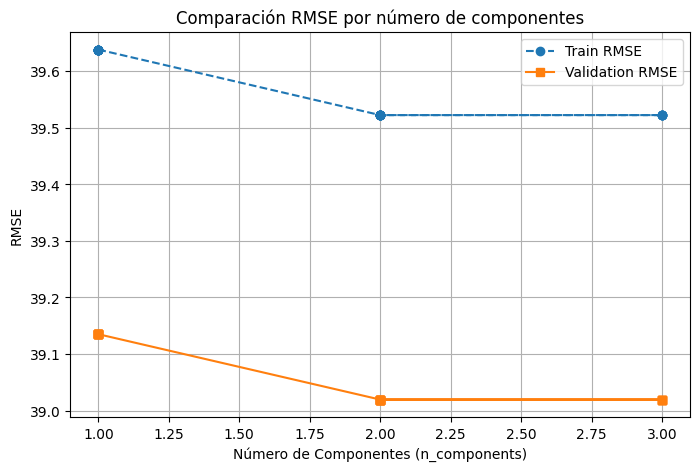

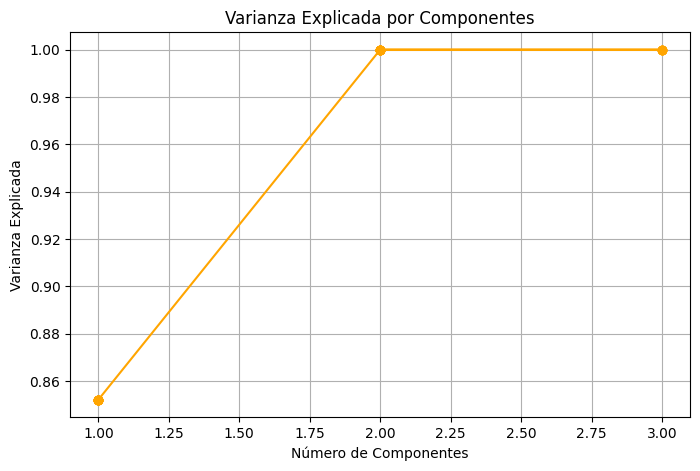

In [ ]:
import matplotlib.pyplot as plt

# --- GRAFICO 1: Comparación RMSE ---
plt.figure(figsize=(8, 5))
plt.plot(results_df['n_components'], results_df['val_rmse'], 'o-', label='Validación RMSE')
plt.plot(results_df['n_components'], results_df['train_rmse'], 's--', label='Entrenamiento RMSE')
plt.xlabel('Número de componentes (SVD)')
plt.ylabel('RMSE')
plt.title('Error según número de componentes')
plt.legend()
plt.grid(True)
plt.show()

# --- GRAFICO 2: Varianza explicada ---
plt.figure(figsize=(8, 5))
plt.bar(results_df['n_components'], results_df['variance_explained'], color='skyblue')
plt.xlabel('Numero de componentes')
plt.ylabel('Varianza explicada')
plt.title('Varianza explicada por SVD')
plt.grid(axis='y')
plt.show()

# --- GRAFICO 3: Predicciones vs Reales ---
best_model = SVDRegression(
    n_components=int(best_model_params['n_components']),
    algorithm=best_model_params['algorithm'],
    random_state=int(best_model_params['random_state'])
)
best_model.fit(X_train, y_train.values.ravel())
y_pred = best_model.predict(X_val)

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales")
plt.grid(True)
plt.show()
